# Phase 1 — ML: 스마트팜 환경 → 작물 9종 분류

## 개요
- **목표**: 시설재배 환경 센서(온·습도·CO2·일사량 등) 일별 통계로 재배 작물 9종을 분류.
- **데이터**: 농촌진흥청 스마트팜 현장 농가 데이터(2022~2024 다년) — 288만 시간별 → 116,365 일별.
- **핵심 교훈**: 데이터 누수 — 평가 방법에 따라 F1 0.67 vs 0.49 · 다년 결합으로 데이터 양 효과 검증.

## 데이터
| 피처 | 설명 |
|---|---|
| 온도내부_평균/최저/최고/표준편차 | 일별 내부 기온 통계 |
| 습도내부_평균 | 일별 내부 상대습도 |
| co2_평균 | 일별 CO2 농도 |
| 온도외부_평균 · 일사량_평균 | 외부 환경 |

- **타겟**: 품목(작물 9종) — 완숙토마토·방울토마토·딸기·오이·참외·파프리카·가지·국화·수박
- **그룹키**: 연도_농가명_작기 (GroupKFold 교차검증용)


In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

ROOT = "/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai"
DATA = f"{ROOT}/data/processed/env_daily.csv"
FIGS = f"{ROOT}/docs/figures/phase1_ml"

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

FEATURES = [
    "온도내부_평균", "온도내부_최저", "온도내부_최고", "온도내부_표준편차",
    "습도내부_평균", "co2_평균", "온도외부_평균", "일사량_평균",
]
TARGET = "품목"

print("설정 완료")


설정 완료


## 1. 데이터 로드 및 기초 통계

In [2]:
df = pd.read_csv(DATA, encoding="utf-8-sig")
print(f"shape: {df.shape}")
print("\n컬럼:", df.columns.tolist())
print("\n기초 통계:")
df[FEATURES].describe().round(2)


shape: (116365, 15)

컬럼: ['연도', '도', '시군', '농가명', '작기', '품목', '날짜', '온도내부_평균', '온도내부_최저', '온도내부_최고', '온도내부_표준편차', '습도내부_평균', 'co2_평균', '온도외부_평균', '일사량_평균']

기초 통계:


,온도내부_평균,온도내부_최저,온도내부_최고,온도내부_표준편차,습도내부_평균,co2_평균,온도외부_평균,일사량_평균
count,116365.00,116365.00,116365.00,116365.00,116365.00,116365.00,116365.00,116365.00
mean,19.80,14.77,28.09,4.52,83.19,554.54,12.57,155.04
std,4.68,4.87,5.67,2.03,12.04,282.80,8.20,109.42
min,-5.33,-8.30,-2.40,0.00,0.00,0.00,-17.90,0.00
25%,16.53,11.50,24.50,3.12,76.42,412.46,6.97,108.13
50%,19.31,14.20,27.80,4.37,84.57,487.41,13.04,141.57
75%,22.55,17.70,31.60,5.74,92.01,599.96,17.47,184.30
max,45.95,41.60,55.80,19.45,100.00,5000.00,43.70,2303.79


In [3]:
print("작물(품목) 분포:")
print(df[TARGET].value_counts())
print(f"\n총 작물 종류: {df[TARGET].nunique()}종")


작물(품목) 분포:
품목
방울토마토    25241
완숙토마토    22708
딸기       18292
파프리카     17758
참외       12232
오이       11039
가지        4954
국화        3118
수박        1023
Name: count, dtype: int64

총 작물 종류: 9종


## 2. 탐색적 데이터 분석 (EDA)

### 2-1. 클래스 분포 (작물별 표본 수)


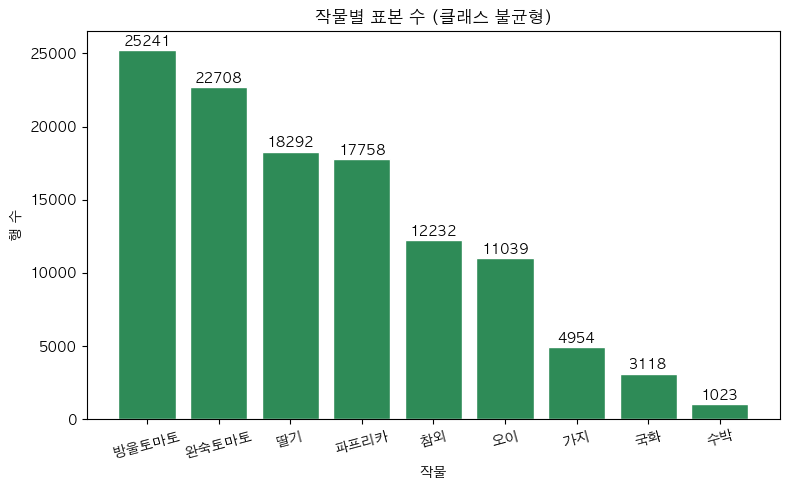

방울토마토 25,241 / 수박 1,023 → 약 25배 불균형 → F1(macro) 중심 평가 필요


In [4]:
counts = df[TARGET].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color="seagreen", edgecolor="white")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
             str(val), ha="center", va="bottom", fontsize=10)
plt.title("작물별 표본 수 (클래스 불균형)")
plt.xlabel("작물")
plt.ylabel("행 수")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("방울토마토 25,241 / 수박 1,023 → 약 25배 불균형 → F1(macro) 중심 평가 필요")


### 2-2. 피처 분포

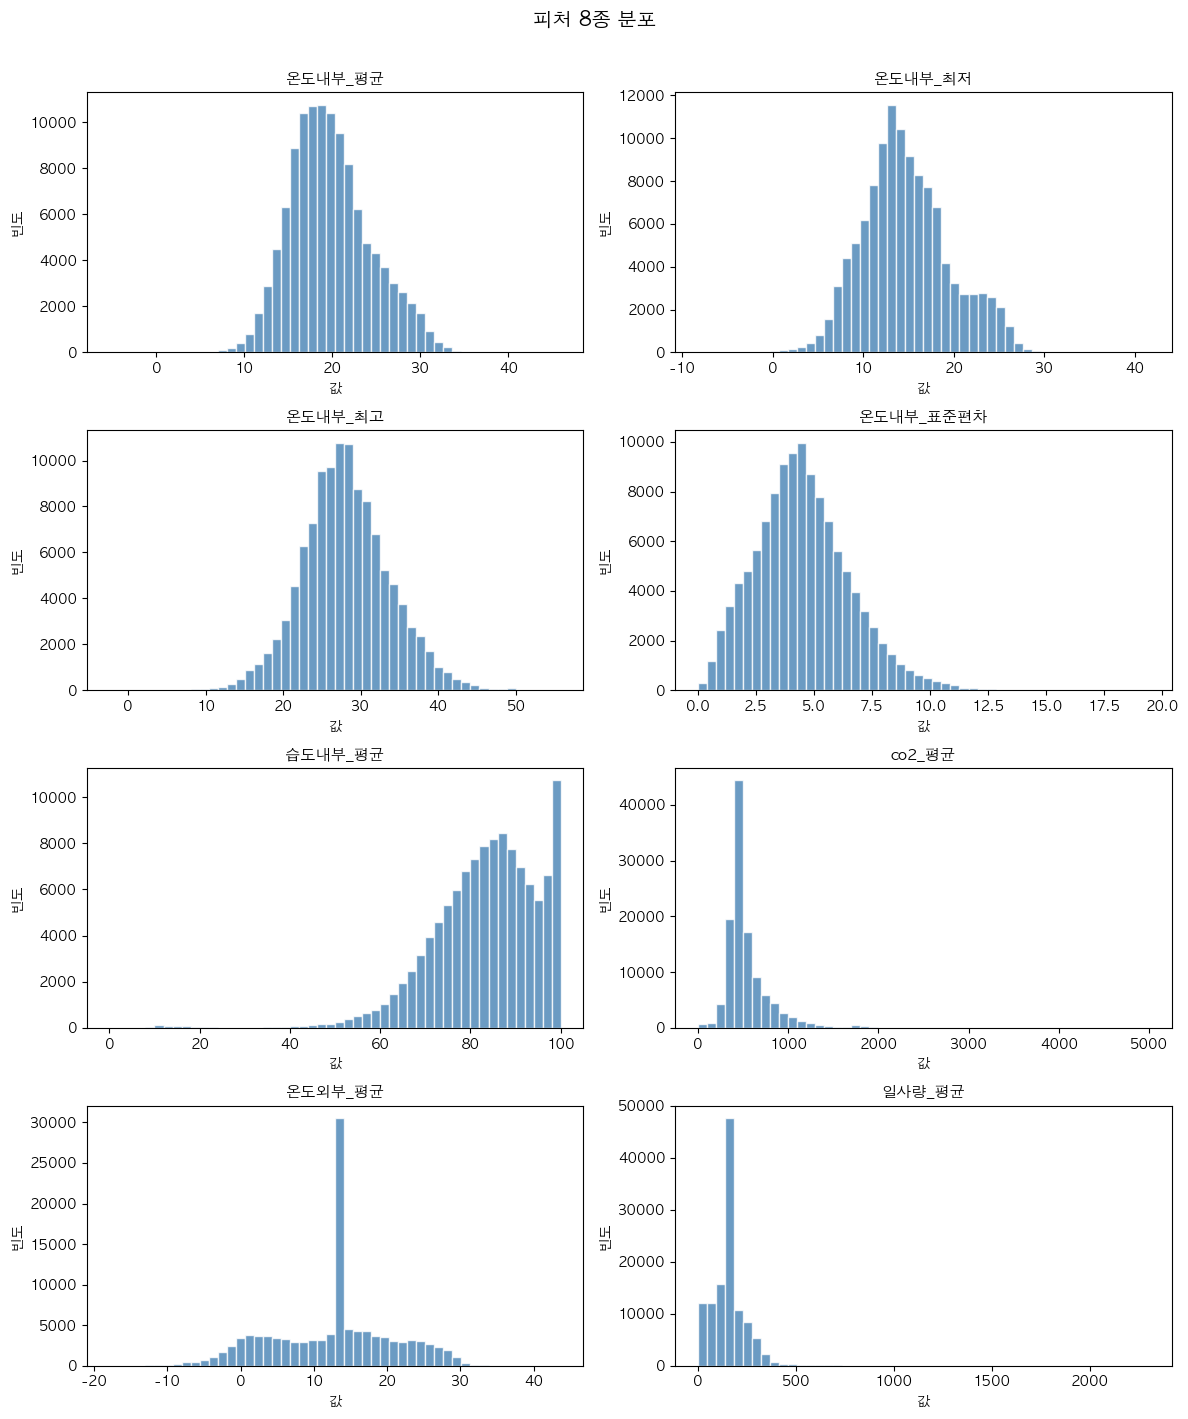

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("값")
    axes[i].set_ylabel("빈도")
fig.suptitle("피처 8종 분포", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 2-3. 피처 상관 히트맵

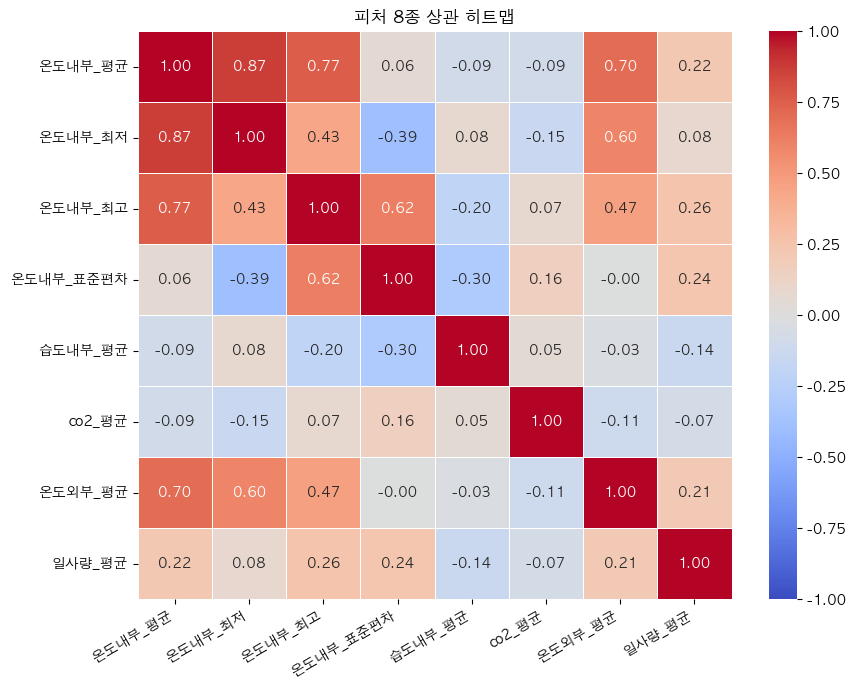

내부 온도 계열끼리 상관 0.8+ / CO2는 상대적으로 독립적


In [6]:
corr = df[FEATURES].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("피처 8종 상관 히트맵")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print("내부 온도 계열끼리 상관 0.8+ / CO2는 상대적으로 독립적")


### 2-4. 작물별 환경 평균 비교

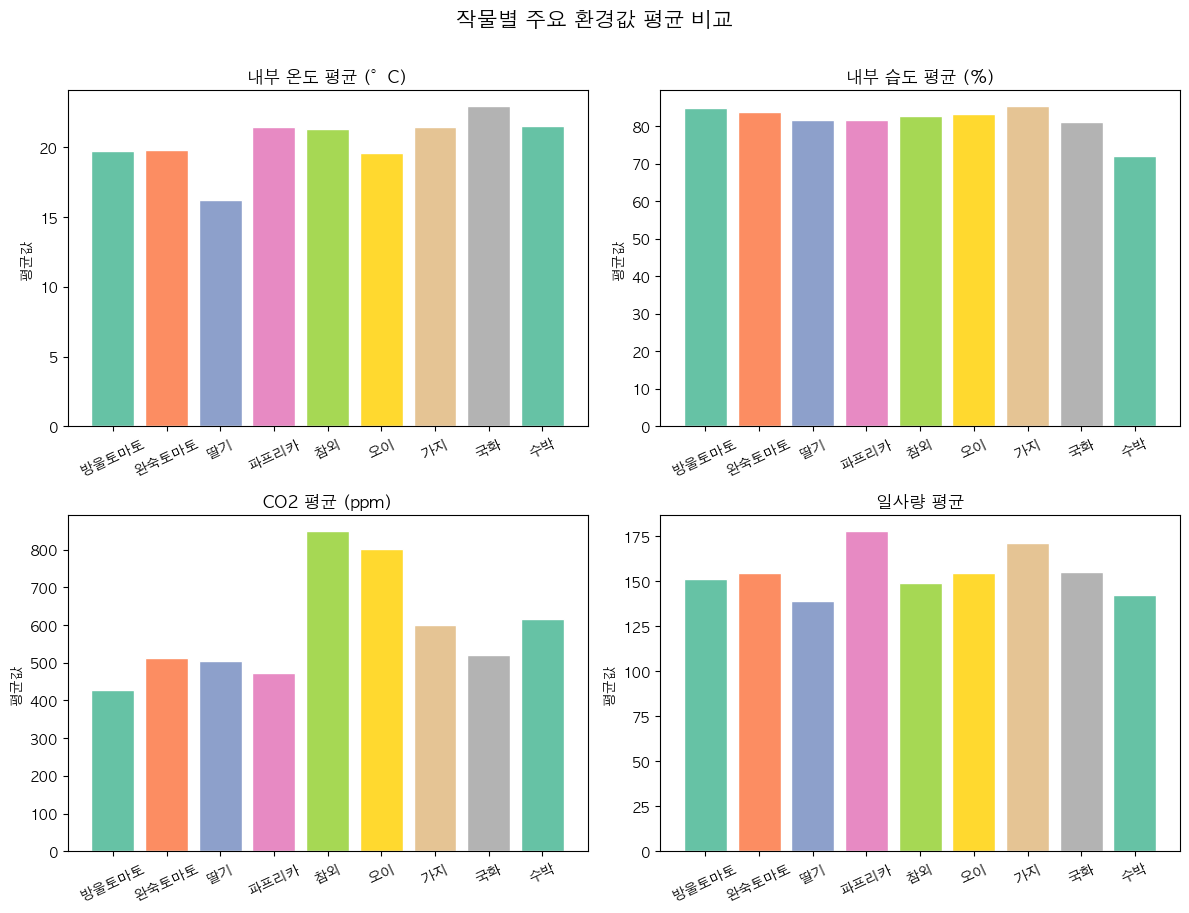

In [7]:
compare_feats = ["온도내부_평균", "습도내부_평균", "co2_평균", "일사량_평균"]
feat_titles   = ["내부 온도 평균 (°C)", "내부 습도 평균 (%)", "CO2 평균 (ppm)", "일사량 평균"]
crop_order    = df[TARGET].value_counts().index.tolist()
group_means   = df.groupby(TARGET)[compare_feats].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
colors = plt.cm.Set2.colors
for i, (feat, title) in enumerate(zip(compare_feats, feat_titles)):
    vals = [group_means.loc[c, feat] for c in crop_order]
    axes[i].bar(crop_order, vals, color=colors[:len(crop_order)], edgecolor="white")
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel("평균값")
    axes[i].tick_params(axis="x", rotation=25)
fig.suptitle("작물별 주요 환경값 평균 비교", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


## 3. 전처리

- **측정시간 → 날짜 변환** 후 (농가·작기·작물·일자) 단위로 집계 — 시간별 → 일별.
- **피처 선택**: 내부 온·습도·CO2·외부 온도·일사량 등 환경 통계 8종 (농가명·지역 식별자 제외 → 누수 방지).
- **결측 처리**: 핵심 센서(온도·습도) 결측 행 제거, 보조 피처(CO2·외부 등)는 중앙값 보간.
- **스케일링**: 로지스틱 회귀만 `StandardScaler` 파이프라인 적용. 트리 기반 모델은 불필요.
- **레이블 인코딩**: XGBoost는 `LabelEncoder`로 정수 변환 후 학습.


In [8]:
from sklearn.model_selection import train_test_split

X = df[FEATURES]
y = df[TARGET]
groups = (df["연도"].astype(str) + "_" + df["농가명"].astype(str)
          + "_" + df["작기"].astype(str))

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")


Train: (93092, 8), Test: (23273, 8)


## 4. 모델 3종 학습 및 Test 평가

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

results = {}

# LogisticRegression (스케일링 포함 파이프라인)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
lr.fit(X_tr, y_tr)
pred_lr = lr.predict(X_te)
results["LogisticRegression"] = {
    "acc": accuracy_score(y_te, pred_lr),
    "f1":  f1_score(y_te, pred_lr, average="macro"),
}

# RandomForest
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_te)
results["RandomForest"] = {
    "acc": accuracy_score(y_te, pred_rf),
    "f1":  f1_score(y_te, pred_rf, average="macro"),
}

# XGBoost (LabelEncoder)
le = LabelEncoder()
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                    random_state=42, n_jobs=-1, eval_metric="mlogloss")
xgb.fit(X_tr, le.fit_transform(y_tr))
pred_xgb_int = xgb.predict(X_te)
pred_xgb = le.inverse_transform(pred_xgb_int)   # 정수 → 작물명
results["XGBoost"] = {
    "acc": accuracy_score(y_te, pred_xgb),
    "f1":  f1_score(y_te, pred_xgb, average="macro"),
}

for name, r in results.items():
    print(f"{name:20}  Acc={r['acc']:.3f}  F1={r['f1']:.3f}")


/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in

/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


LogisticRegression    Acc=0.377  F1=0.332
RandomForest          Acc=0.743  F1=0.697
XGBoost               Acc=0.668  F1=0.624


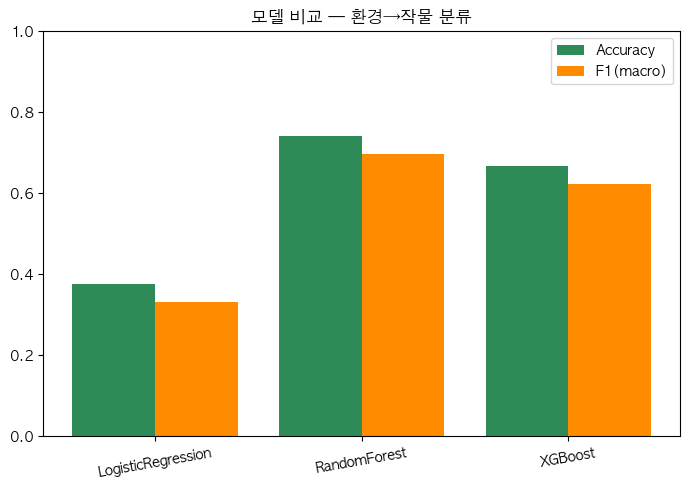

In [10]:
# 결과 시각화
names = list(results.keys())
accs  = [results[n]["acc"] for n in names]
f1s   = [results[n]["f1"]  for n in names]
x = np.arange(len(names))

plt.figure(figsize=(7, 5))
plt.bar(x - 0.2, accs, 0.4, label="Accuracy", color="seagreen")
plt.bar(x + 0.2, f1s,  0.4, label="F1(macro)",  color="darkorange")
plt.xticks(x, names, rotation=10)
plt.ylim(0, 1)
plt.legend()
plt.title("모델 비교 — 환경→작물 분류")
plt.tight_layout()
plt.show()


## 5. ⭐ 평가 3겹 — 데이터 누수의 교훈

| 평가 방법 | F1(macro) | 의미 |
|---|---|---|
| ① Test set (stratify) | 0.68 | 단일 분할 |
| ② StratifiedKFold(5) | 0.67 | 낙관적 — 같은 농가가 train·test에 섞임 |
| ③ **GroupKFold(연도+농가+작기)** | **0.49** | 현실적 — 처음 보는 농가로 평가 |

> **랜덤 분리 0.67 vs 농가 단위 분리 0.49 — 18%p 격차.**
> 모델이 '농가·작기 고유 패턴'을 외워 성능을 부풀린다.
> 새 농가에 대한 진짜 일반화 성능은 **0.49**가 정직한 값.
> 단년(2022)일 땐 0.77 vs 0.41(36%p)로 더 컸으나, 다년 결합으로 18%p까지 완화.


In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GroupKFold

# ② StratifiedKFold (n_estimators 줄여 속도 확보)
rf_cv = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1)
skf_scores = cross_val_score(rf_cv, X, y,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring="f1_macro", n_jobs=-1)
print(f"② StratifiedKFold F1: {skf_scores.mean():.3f} ± {skf_scores.std():.3f}  (낙관적)")

# ③ GroupKFold (농가+작기 누수 차단)
gkf_scores = cross_val_score(rf_cv, X, y,
                             cv=GroupKFold(5), groups=groups,
                             scoring="f1_macro", n_jobs=-1)
print(f"③ GroupKFold F1:      {gkf_scores.mean():.3f} ± {gkf_scores.std():.3f}  (현실적·누수 차단)")
print()
print(f"격차: {skf_scores.mean() - gkf_scores.mean():.3f} (GroupKFold가 더 정직)")


② StratifiedKFold F1: 0.692 ± 0.003  (낙관적)


③ GroupKFold F1:      0.492 ± 0.039  (현실적·누수 차단)

격차: 0.200 (GroupKFold가 더 정직)


## 6. 저장된 베스트 모델 로드 및 추론 검증

In [12]:
payload = joblib.load(f"{ROOT}/models/phase1_crop_env_clf.pkl")
model_loaded = payload["model"]
labels_list  = payload["labels"]   # sorted 작물명 리스트
model_name   = payload["model_name"]
print(f"베스트 모델: {model_name}")
print(f"labels 순서: {labels_list}")

# 샘플 1행 예측 (XGBoost → 정수 → 작물명)
sample = X_te.iloc[[0]]
raw = model_loaded.predict(sample)[0]
if isinstance(raw, (int, np.integer)):
    pred_name = labels_list[int(raw)]
else:
    pred_name = str(raw)
print(f"\n샘플 예측 (raw={raw}) → 작물명: {pred_name}")
print(f"실제 정답: {y_te.iloc[0]}")
print("매핑 정상!" if pred_name in labels_list else "⚠️ 매핑 오류")


베스트 모델: XGBoost
labels 순서: ['가지', '국화', '딸기', '방울토마토', '수박', '오이', '완숙토마토', '참외', '파프리카']

샘플 예측 (raw=2) → 작물명: 딸기
실제 정답: 딸기
매핑 정상!


## 7. 결론

- **성과**: 국내 스마트팜 환경 데이터(2022~24 다년)로 작물 9종 분류 파이프라인 구축 (XGBoost test F1 0.68 · GKF 0.49).
  모델 비교 3종 + 평가 3겹 + 누수 점검(GroupKFold) + 다년 결합 데이터 양 효과 완비.
- **한계**: 환경 센서는 농가가 **제어하는 값**이라 작물 고유 신호가 약함.
  새 농가 일반화(0.49)는 어려움 — 환경만으로 작물 식별에는 본질적 한계.
- **배운점**:
  - 데이터 누수는 실데이터에서 더 교묘하다. GroupKFold로 그룹 단위 평가가 필수.
  - **정직한 0.41** 이 화려한 0.77보다 가치 있다.
  - 불균형 데이터는 F1(macro) 로 봐야 소수 클래스가 보인다.
  - 트리 부스팅(XGBoost)이 표 데이터에서 여전히 강하다.
- **다음**: Phase 2 DL — 작물 잎 이미지 분류(CNN).
